In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
from tqdm import tqdm

import jax
from jax import jit
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from functools import partial

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

[gpu(id=0)]


In [2]:
sys.path.append("../..")
from models.np_model import NPModel
from simulations.wrapper import simulator_for_model
from models.scd import dnds
from likelihoods.npll_jax import log_like_np

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
npmodel = NPModel(
    non_poissonian=True, l_max=2,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/fit_np_to_np/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


## 1. Generate counts

### 1.1 everything

In [4]:
S_Sps_arr = [[1.5, 0.01], [0.75, 0.75], [0.01, 1.5]]
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    var_dict = dict(
        theta_pib = np.array([1., 0., 0.]), # O A F
        theta_ics = np.array([1., 0., 0.]),
        S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
        Sps_dsk = 1.3, zs = 0.5, C = 2.5,
        S_gce = S_gce, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
        Sps_gce = Sps_gce, gamma_ps = 1.2, f_bulge_ps = 0.3,
        theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
        theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
        n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
        Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
    )
    pickle.dump(var_dict, open(f"data/truth-{run_name}.p", 'wb'))

    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"data/counts-{run_name}.npy", counts)

S1.500Sps0.010


/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


S0.750Sps0.750
S0.010Sps1.500


### 1.2 bare: just gce

In [66]:
S_Sps_arr = [[5., 0.01], [2.5, 2.5], [0.01, 5.]]
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    var_dict = dict(
        theta_pib = np.array([1., 0., 0.]), # O A F
        theta_ics = np.array([1., 0., 0.]),
        S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 0., S_ics = 0.,
        Sps_dsk = 0., zs = 0.5, C = 2.5,
        S_gce = S_gce, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
        Sps_gce = Sps_gce, gamma_ps = 1.2, f_bulge_ps = 0.3,
        theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
        theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
        n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
        n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
        Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
    )
    pickle.dump(var_dict, open(f"truth-{run_name}-bare.p", 'wb'))

    counts = simulator_for_model(npmodel, var_dict)
    np.save(f"counts-{run_name}-bare.npy", counts)

S5.000Sps0.010
S2.500Sps2.500
S0.010Sps5.000


### 1.3 np_np (full model)

In [41]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.3, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
pickle.dump(var_dict, open(f"truth-{run_name}-npnp.p", 'wb'))

counts = simulator_for_model(npmodel, var_dict)
np.save(f"counts-{run_name}-npnp.npy", counts)

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


### 1.4 np_np (full model) flat exposure

In [27]:
npmodel = NPModel(
    non_poissonian=True, l_max=2,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
    use_flat_exposure=True,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/fit_np_to_np/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [10]:
npmodel.exposure_map

array([8.92665862e+10, 8.92665862e+10, 8.92665862e+10, ...,
       8.92665862e+10, 8.92665862e+10, 8.92665862e+10])

In [11]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.0, zs = 0.5, C = 2.5,
    S_gce = 1.0, gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 2.0, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
pickle.dump(var_dict, open(f"data/truth-npnp-flatexp.p", 'wb'))

for i in tqdm(range(8)):
    counts = simulator_for_model(npmodel, var_dict)
    #np.save(f"data/counts-npnp-flatexp-{i}.npy", counts)

  0%|          | 0/8 [00:00<?, ?it/s]

Uniform check: min, max =  89266586245.44127 89266586245.44127


 12%|█▎        | 1/8 [00:18<02:07, 18.23s/it]

Uniform check: min, max =  89266586245.44127 89266586245.44127


 25%|██▌       | 2/8 [00:23<01:03, 10.54s/it]

...

 75%|███████▌  | 6/8 [00:44<00:11,  5.96s/it]

Uniform check: min, max =  89266586245.44127 89266586245.44127


 88%|████████▊ | 7/8 [00:49<00:05,  5.71s/it]

Uniform check: min, max =  89266586245.44127 89266586245.44127


100%|██████████| 8/8 [00:54<00:00,  6.82s/it]


### 1.4 view

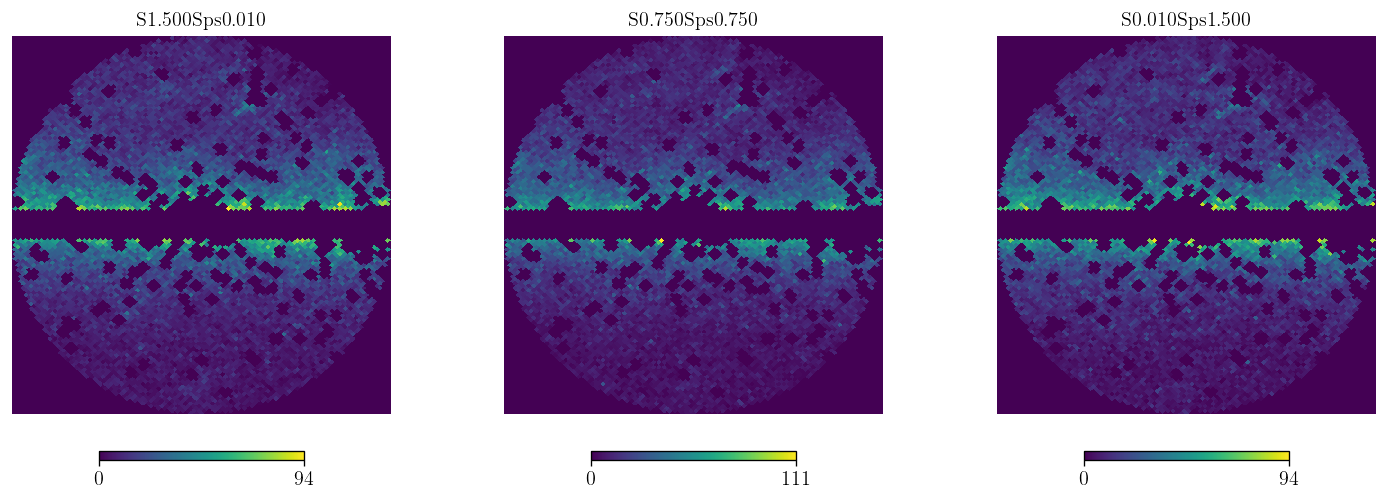

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

S_Sps_arr = [[1.5, 0.01], [0.75, 0.75], [0.01, 1.5]]
ll_arr_arr = []
for i, (S_gce, Sps_gce) in enumerate(S_Sps_arr):
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"

    counts = jnp.array(jnp.load(f"data/counts-{run_name}.npy"), dtype=np.int32)

    plt.sca(axs[i])
    hp.cartview(counts, lonra=[-25, 25], latra=[-25, 25], hold=True, title=run_name)

## 2. Likelihood

In [4]:
from ll import ll, ll_justSps, ll_dsk#, ll_gce

In [6]:
S_Sps_arr = [[1.5, 0.01], [0.75, 0.75], [0.01, 1.5]]
ll_arr_arr = []
for S_gce, Sps_gce in S_Sps_arr:
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    print(run_name)

    counts = jnp.array(jnp.load(f"data/counts-{run_name}.npy"), dtype=np.int32)
    var_dict = pickle.load(open(f"data/truth-{run_name}.p", 'rb'))

    S_arr = np.geomspace(1e-2, 3, 30)
    Sps_arr = np.geomspace(1e-2, 3, 30)
    ll_arr = np.zeros((len(S_arr), len(Sps_arr)))
    for i_S, S in enumerate(tqdm(S_arr)):
        for i_Sps, Sps in enumerate(Sps_arr):
            ll_arr[i_S, i_Sps] = ll(npmodel, var_dict, counts, S, Sps)
    ll_arr_arr.append(ll_arr)

S1.500Sps0.010


100%|██████████| 30/30 [00:49<00:00,  1.64s/it]


S0.750Sps0.750


100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


S0.010Sps1.500


100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


/tmp/ipykernel_2925219/2578599796.py:6: UserWarning: The following kwargs were not used by contour: 'aspect'
  ct = axs[i].contour((Sps_arr), (S_arr), ll_arr-np.max(ll_arr), levels=[-1000, -500, -250, -100, -50, -25, -10], aspect=1)


Text(0.5, 0.98, 'Likelihood (full model, truth values for variables not shown)')

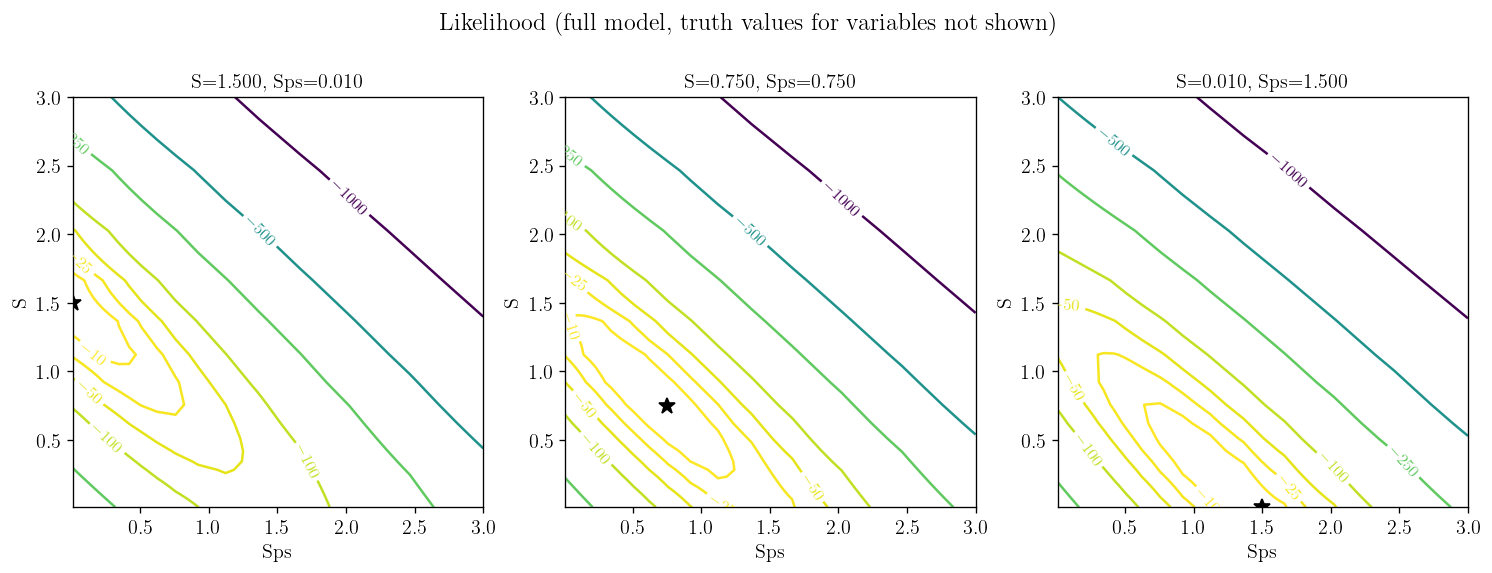

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, ll_arr in enumerate(ll_arr_arr):
    S_gce, Sps_gce = S_Sps_arr[i]
    run_name = f"S{S_gce:.3f}Sps{Sps_gce:.3f}"
    # show contour labels
    ct = axs[i].contour((Sps_arr), (S_arr), ll_arr-np.max(ll_arr), levels=[-1000, -500, -250, -100, -50, -25, -10], aspect=1)
    axs[i].clabel(ct, inline=True, fontsize=10)
    axs[i].set(aspect=1)
    axs[i].set(xlabel="Sps", ylabel="S", title=f'S={S_gce:.3f}, Sps={Sps_gce:.3f}')
    axs[i].plot(Sps_gce, S_gce, '*', color='k', ms=10)
fig.suptitle('Likelihood (full model, truth values for variables not shown)')

In [5]:
npmodel = NPModel(
    non_poissonian=True, l_max=2,
    dif_names=["ModelO", "ModelA", "ModelF"],
    bulge_hybrid=True,
    bulge_template_names=["mcdermott2022", "mcdermott2022_bbp", "mcdermott2022_x", "macias2019", "coleman2019"],
    vary_gamma=True,
    vary_disk=True,
    ps_cat="3fgl", r_outer=25, band_mask_range=2.,
    nside=128, n_exp=1, debug_model=False,
    use_flat_exposure=True,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/fit_np_to_np/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [35]:
ll_arr_arr = []

for i_counts in range(8):
    counts = jnp.array(jnp.load(f"../../outputs/justSps/counts_{i_counts}.npy"), dtype=jnp.int32)
    var_dict = pickle.load(open(f"../../outputs/justSps/truth.p", 'rb'))

    var_dict['S_iso'] = 1e-6

    k1 = 'Sps_gce'
    k2 = 'Sps_dsk'

    Sk1_arr = np.linspace(1, 3, 30)
    Sk2_arr = np.linspace(1e-2, 2, 31)
    ll_arr = np.zeros((len(Sk1_arr), len(Sk2_arr)))
    for i_1, Sk1 in enumerate(tqdm(Sk1_arr)):
        for i_2, Sk2 in enumerate(Sk2_arr):
            vd_in = var_dict.copy()
            vd_in.update({k1: Sk1, k2: Sk2})
            ll_arr[i_1, i_2] = ll_justSps(npmodel, vd_in, counts)
    ll_arr_arr.append(ll_arr)

100%|██████████| 30/30 [00:22<00:00,  1.32it/s]


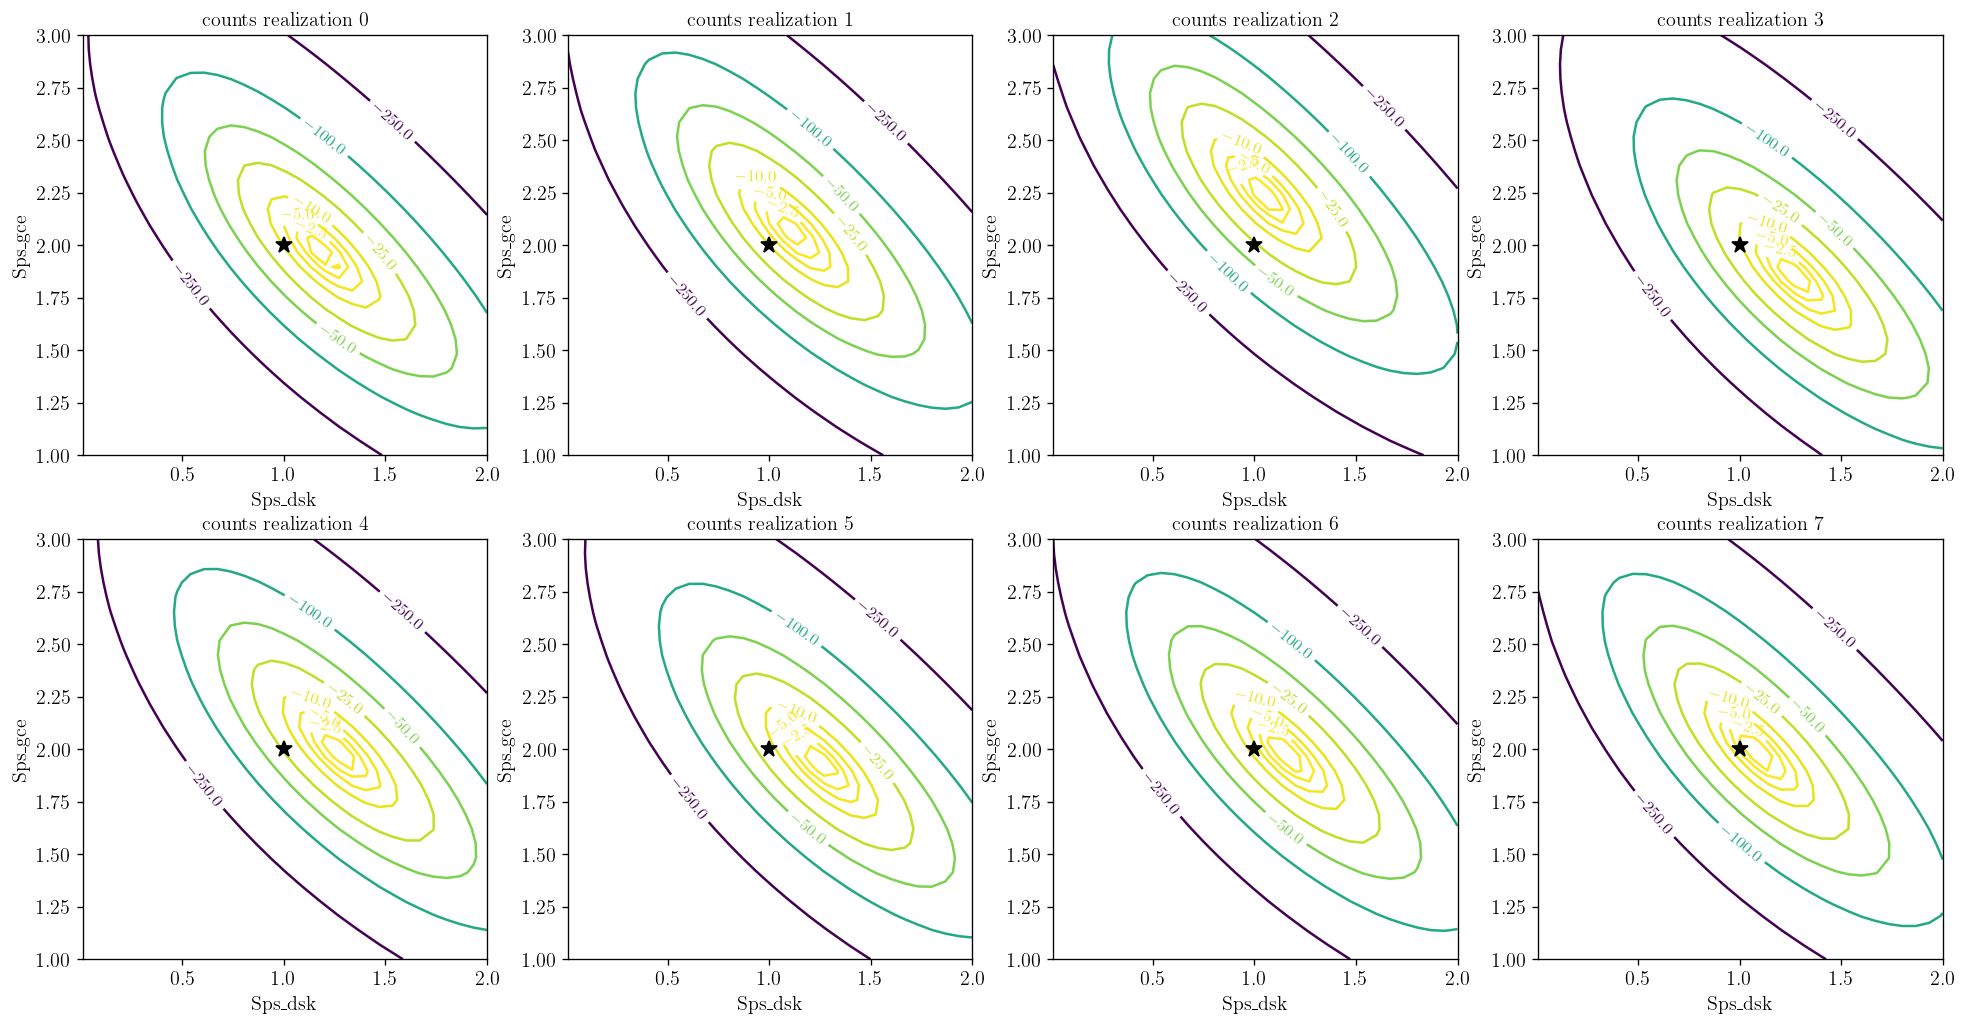

In [36]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# 2 is x, 1 is y

for i in range(8):
    ax = axs[i//4, i%4]
    ll_arr = ll_arr_arr[i]
    ct = ax.contour((Sk2_arr), (Sk1_arr), ll_arr-np.max(ll_arr), levels=[-250, -100, -50, -25, -10, -5, -2.5, -1])
    ax.clabel(ct, inline=True, fontsize=10)
    #ax.set(aspect=1)
    ax.set(xlabel=k2, ylabel=k1, title=f'counts realization {i}')
    ax.plot(var_dict[k2], var_dict[k1], '*', color='k', ms=10);

In [ ]:
from utils.utils import find_max_point

In [12]:
ll_arr_arr = []
counts_arr = []

for i_counts in tqdm(range(100)):
    counts = jnp.array(jnp.load(f"../../outputs/justSps/counts_{i_counts}.npy"), dtype=jnp.int32)
    counts_arr.append(np.sum(counts))
    var_dict = pickle.load(open(f"../../outputs/justSps/truth.p", 'rb'))

    ll_func = ll_justSps

    k = 'Sps_gce'

    Sk_arr = np.linspace(1.5, 2.5, 31)
    ll_arr = np.zeros((len(Sk_arr),))
    for i, Sk in enumerate(Sk_arr):
        vd_in = var_dict.copy()
        vd_in.update({k: Sk})
        ll_arr[i] = ll_func(npmodel, vd_in, counts)
    ll_arr_arr.append(ll_arr)
counts_arr = np.array(counts_arr)

100%|██████████| 100/100 [00:57<00:00,  1.73it/s]


[(-10.0, 5.0)]

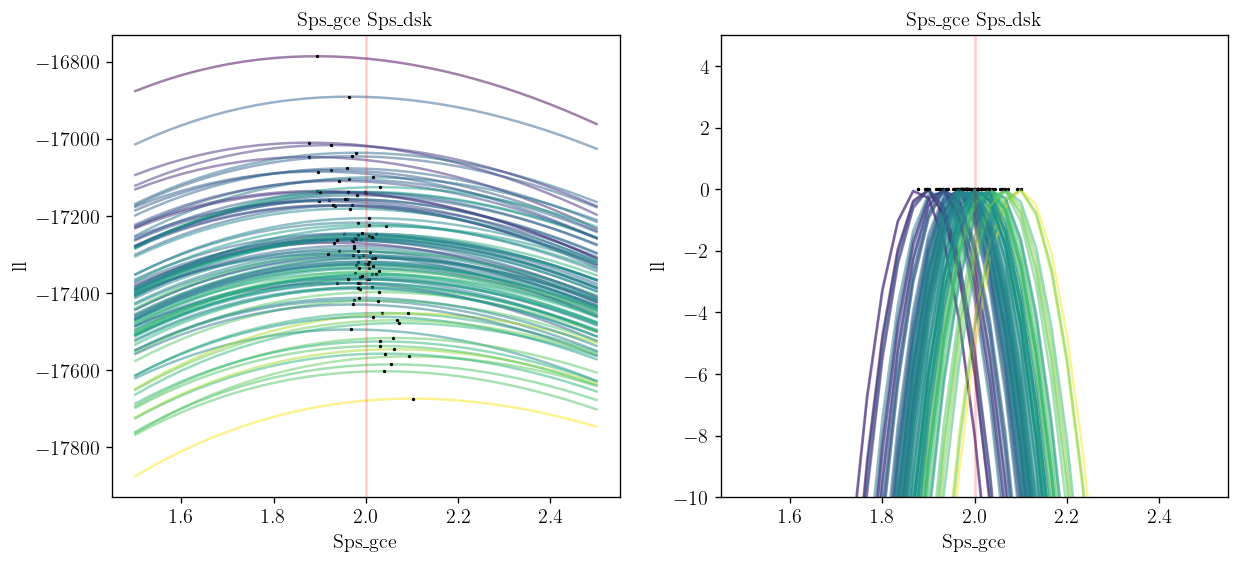

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 2 is x, 1 is y

for i, ll_arr in enumerate(ll_arr_arr):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    ax.plot(Sk_arr, ll_arr, color=color, alpha=0.5)
    Sm, llm = find_max_point(Sk_arr, ll_arr)
    ax.plot(Sm, llm, 'k.', ms=2)

    ax = axs[1]
    ax.plot(Sk_arr, ll_arr - llm, color=color, alpha=0.5)
    ax.plot(Sm, llm - llm, 'k.', ms=2)
axs[0].axvline(var_dict[k], color='r', alpha=0.2)
axs[1].axvline(var_dict[k], color='r', alpha=0.2)
axs[0].set(xlabel=k, ylabel='ll', title='Sps_gce Sps_dsk')
axs[1].set(xlabel=k, ylabel='ll', title='Sps_gce Sps_dsk')
axs[1].set(ylim=(-10, 5))

### comapre with posterior

In [ ]:
from utils.multi_corner import multi_corner

In [38]:
save_dir = "../../outputs/np_np"
samples_fn_list = [f for f in os.listdir(save_dir) if f.startswith("hmc_samples") and not f.endswith("noNT.p")]
n_run = len(samples_fn_list)
truth_dict = pickle.load(open(f"{save_dir}/truth.p", 'rb'))

In [39]:
svi_samples_list = []
mean_arr = []
for samples_fn in tqdm(samples_fn_list):
    svi_samples_list.append(pickle.load(open(f'{save_dir}/{samples_fn}', 'rb')))
    mean_arr.append(np.mean(svi_samples_list[-1]['Sps_gce']))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 84.36it/s]


In [40]:
samples_dict = {
    f'{i}' : s
    for i, s in enumerate(svi_samples_list)
}
colors_dict = {
    f'{i}' : cms['viridis']( (mean_arr[i]-np.min(mean_arr))/(np.max(mean_arr)-np.min(mean_arr)) )
    for i, s in enumerate(svi_samples_list)
}
labels_dict = None
plot_var_names = [
    'S_ics', 'Sps_gce', 'Sps_dsk',
]
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    point_est=truth_dict,
    hist_bin_factor=1, save_fn='hmc-NT.png'
)